In [1]:
import sys
import os

# 1. See the exact paths Python is searching for your modules
print("--- Python Import Paths ---")
for path in sys.path:
    print(path)

--- Python Import Paths ---
/home/theppawan/miniconda3/envs/ml_env/lib/python314.zip
/home/theppawan/miniconda3/envs/ml_env/lib/python3.14
/home/theppawan/miniconda3/envs/ml_env/lib/python3.14/lib-dynload

/home/theppawan/miniconda3/envs/ml_env/lib/python3.14/site-packages
/home/theppawan/nn-models/source


In [2]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from utils.data_reader import load_and_prepare_time_series_data
from utils.trainer import Trainer
from models.baseline_models import LSTMModel

In [6]:
data_url = "https://storage.googleapis.com/covid19-open-data/v3/location/US.csv"

# Safely unpack the data reader results regardless of which version you have
results = load_and_prepare_time_series_data(
    filepath_or_url=data_url,
    target_column=['cumulative_confirmed'],
    date_column="date",
    seq_length=14,
    batch_size=32,
    train_split=0.8,
    fill_missing=True
)

train_loader, val_loader, val_dataset, scaler = results

Fetching data from: https://storage.googleapis.com/covid19-open-data/v3/location/US.csv
Sorting data chronologicall by column: date
Succesfully loaded 991 sequential data points.
Prepared Training batches: 25 | Validation batches: 6


In [7]:
model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1)   
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device="cpu"
    )
trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000)

Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Training complete!


([0.05292319616537474,
  0.018455622914058077,
  0.002271601024974415,
  0.0002588267622313254,
  0.00010209744931575734,
  9.390492798613294e-05,
  0.00011308925763666774,
  0.00011935048102332964,
  0.00010064103815818755,
  0.0001043055408842536,
  8.685941328572895e-05,
  0.00010037325490367836,
  7.91618784575048e-05,
  8.459946084234883e-05,
  7.701904987207084e-05,
  8.48683675449278e-05,
  7.644825702001027e-05,
  8.001765472680369e-05,
  8.299365733357525e-05,
  0.000114213270425514,
  0.00010339241757450846,
  7.645164954279739e-05,
  6.822805299099229e-05,
  8.030012446902465e-05,
  8.498793267369615e-05,
  8.89660962791467e-05,
  7.381790968428478e-05,
  9.090138934008001e-05,
  8.211493512551518e-05,
  6.744487325279019e-05,
  7.57557959975148e-05,
  6.562132122060781e-05,
  5.9915574341650294e-05,
  7.433840458952896e-05,
  7.075606205633537e-05,
  6.828046341577502e-05,
  6.968795327418233e-05,
  0.00010385152221397571,
  7.582745131148279e-05,
  7.650578812909119e-05,
 

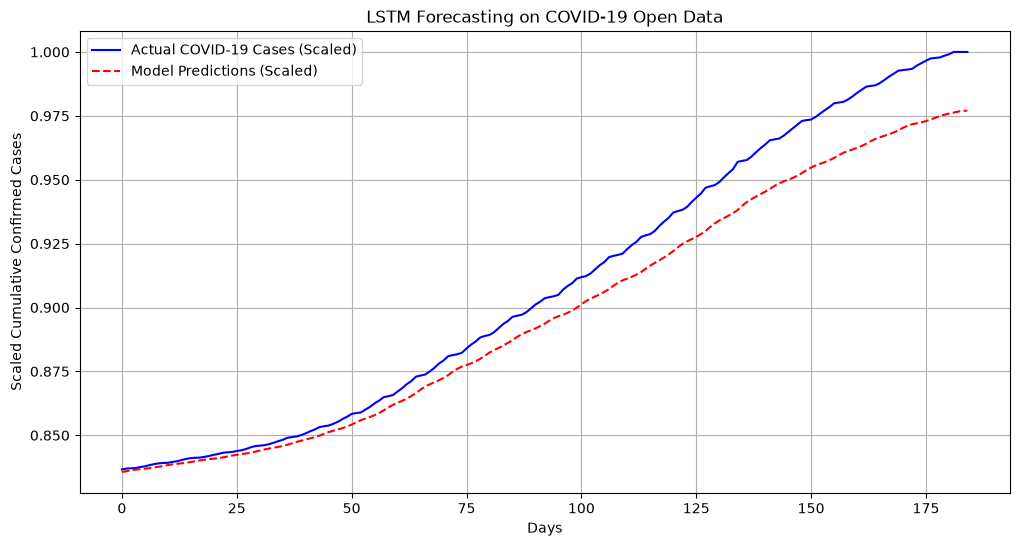

In [10]:
model.eval()
    
actuals = []
predictions = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(trainer.device)
        preds = model(batch_x)
        
        actuals.extend(batch_y.cpu().numpy().flatten())
        predictions.extend(preds.cpu().numpy().flatten())
        
# Plotting the validation data
plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual COVID-19 Cases (Scaled)", color="blue")
plt.plot(predictions, label="Model Predictions (Scaled)", color="red", linestyle="--")
plt.title("LSTM Forecasting on COVID-19 Open Data")
plt.xlabel("Days")
plt.ylabel("Scaled Cumulative Confirmed Cases")
plt.legend()
plt.grid(True)
plt.show()